# Explore Weather Data (4 sources)

Sources, all population-weighted across London/Birmingham/Manchester/Glasgow/Leeds (see `src/edf/data/weather.py`):

1. **Open-Meteo Historical** (ERA5/ERA5-Land reanalysis) — 2020-2025, never available ahead of time in reality.
2. **NASA POWER** — independent reanalysis, 2020-2025, cross-check for #1.
3. **Open-Meteo Nowcast Archive** — short-lead (~0-3h) forecast, 2022-03-01 onward. *Not* a day-ahead forecast (corrected 2026-09-06 — see `PLAN.md`).
4. **Open-Meteo Day-Ahead** (Previous Runs API, `_previous_day1`) — a genuine ~24h-ahead forecast, 2024-03-07 onward.

This notebook checks cross-source agreement and, more importantly, quantifies how much a real forecast (sources 3 and 4) actually diverges from perfect hindsight (source 1) — the honest answer to "how much of a weather feature's benefit survives contact with reality", which Week 4 needs.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PALETTE = {
    "open_meteo_historical": "#0072B2",       # blue
    "nasa_power": "#E69F00",                  # orange
    "open_meteo_nowcast_archive": "#009E73",  # green
    "open_meteo_day_ahead": "#D55E00",        # vermillion
}

SOURCES = list(PALETTE)
sources = {name: pd.read_parquet(f"../data/raw/weather/{name}.parquet").set_index("timestamp")
           for name in SOURCES}

for name, df in sources.items():
    print(f"{name}: {df.shape}, {df.index.min()} -> {df.index.max()}, nulls={df.isna().sum().sum()}")

open_meteo_historical: (52608, 4), 2020-01-01 00:00:00+00:00 -> 2025-12-31 23:00:00+00:00, nulls=0
nasa_power: (52608, 3), 2020-01-01 00:00:00+00:00 -> 2025-12-31 23:00:00+00:00, nulls=0
open_meteo_nowcast_archive: (33648, 4), 2022-03-01 00:00:00+00:00 -> 2025-12-31 23:00:00+00:00, nulls=0
open_meteo_day_ahead: (15960, 4), 2024-03-07 00:00:00+00:00 -> 2025-12-31 23:00:00+00:00, nulls=0


## Full time series: temperature, the two full-range sources

ERA5 and NASA POWER both cover 2020-2025; the other two only start partway through.

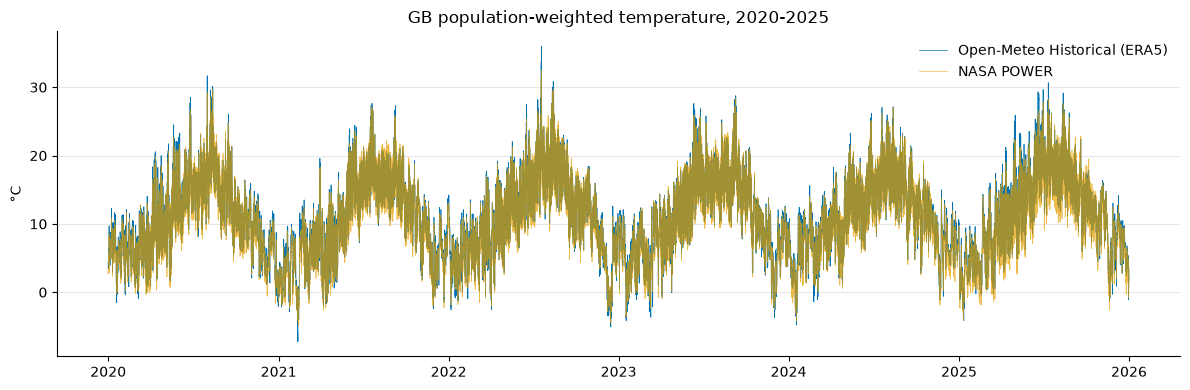

In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sources["open_meteo_historical"].index, sources["open_meteo_historical"]["temperature_c"],
        color=PALETTE["open_meteo_historical"], linewidth=0.5, label="Open-Meteo Historical (ERA5)")
ax.plot(sources["nasa_power"].index, sources["nasa_power"]["temperature_c"],
        color=PALETTE["nasa_power"], linewidth=0.5, alpha=0.7, label="NASA POWER")
ax.set_title("GB population-weighted temperature, 2020-2025")
ax.set_ylabel("°C")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

## Cross-source agreement: ERA5 vs. NASA POWER

Two independent reanalysis products. High correlation with a non-zero spread confirms they're genuinely different sources that happen to agree — not the same data relabelled.

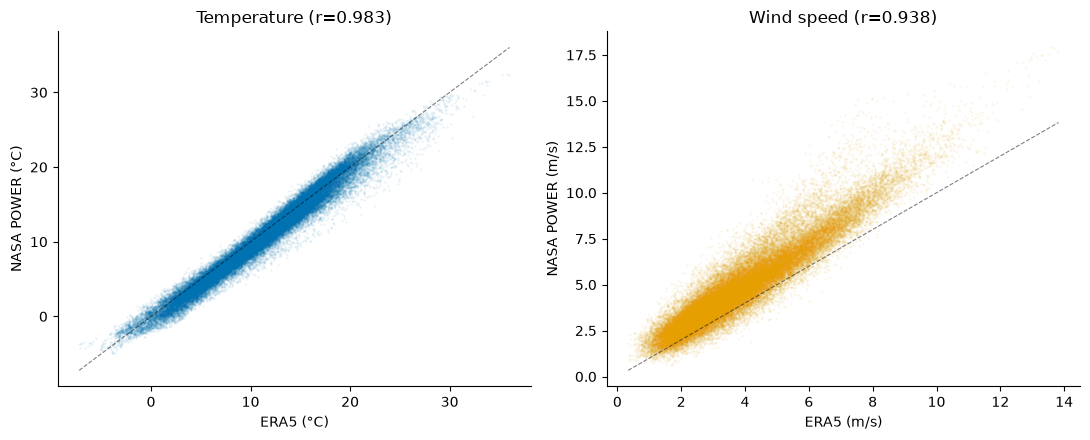

In [3]:
merged = sources["open_meteo_historical"].join(sources["nasa_power"], lsuffix="_om", rsuffix="_nasa")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(merged["temperature_c_om"], merged["temperature_c_nasa"],
                 s=1, alpha=0.05, color=PALETTE["open_meteo_historical"])
lims = [merged["temperature_c_om"].min(), merged["temperature_c_om"].max()]
axes[0].plot(lims, lims, color="black", linewidth=0.8, alpha=0.5, linestyle="--")
corr_t = merged["temperature_c_om"].corr(merged["temperature_c_nasa"])
axes[0].set_title(f"Temperature (r={corr_t:.3f})")
axes[0].set_xlabel("ERA5 (°C)")
axes[0].set_ylabel("NASA POWER (°C)")

axes[1].scatter(merged["wind_speed_ms_om"], merged["wind_speed_ms_nasa"],
                 s=1, alpha=0.05, color=PALETTE["nasa_power"])
lims = [merged["wind_speed_ms_om"].min(), merged["wind_speed_ms_om"].max()]
axes[1].plot(lims, lims, color="black", linewidth=0.8, alpha=0.5, linestyle="--")
corr_w = merged["wind_speed_ms_om"].corr(merged["wind_speed_ms_nasa"])
axes[1].set_title(f"Wind speed (r={corr_w:.3f})")
axes[1].set_xlabel("ERA5 (m/s)")
axes[1].set_ylabel("NASA POWER (m/s)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## Nowcast vs. ERA5: how far does a ~0-3h-lead forecast drift from hindsight?

Over the 2022-03-01 to 2025-12-31 overlap. If this is close to zero, the nowcast is nearly as good as perfect hindsight (expected, given the short lead time).

Nowcast vs ERA5 temperature MAE: 0.972 °C
Nowcast vs ERA5 temperature bias (mean signed error): 0.874 °C


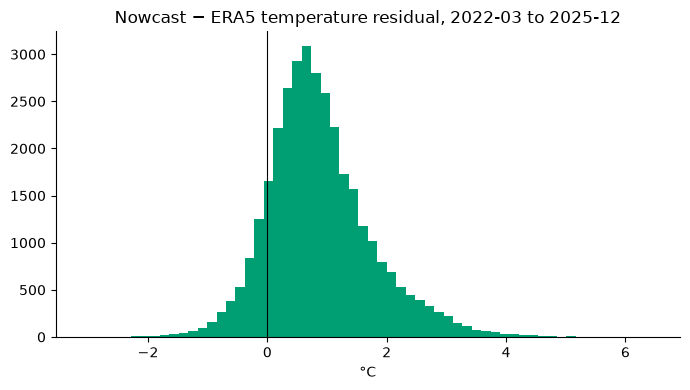

In [4]:
overlap = sources["open_meteo_nowcast_archive"].join(
    sources["open_meteo_historical"], lsuffix="_nowcast", rsuffix="_era5", how="inner"
)
residual = overlap["temperature_c_nowcast"] - overlap["temperature_c_era5"]
print(f"Nowcast vs ERA5 temperature MAE: {residual.abs().mean():.3f} °C")
print(f"Nowcast vs ERA5 temperature bias (mean signed error): {residual.mean():.3f} °C")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(residual, bins=60, color=PALETTE["open_meteo_nowcast_archive"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Nowcast − ERA5 temperature residual, 2022-03 to 2025-12")
ax.set_xlabel("°C")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## Day-ahead vs. ERA5: the honest Week 4 preview

Over the 2024-03-07 to 2025-12-31 overlap.

Day-ahead vs ERA5 temperature MAE: 0.812 °C
Day-ahead vs ERA5 temperature bias: 0.608 °C


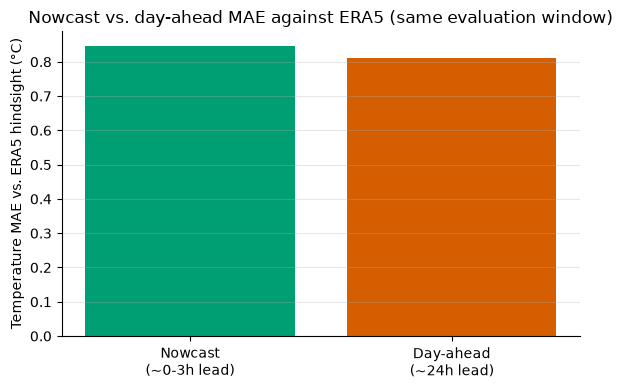

In [5]:
overlap_da = sources["open_meteo_day_ahead"].join(
    sources["open_meteo_historical"], lsuffix="_da", rsuffix="_era5", how="inner"
)
residual_da = overlap_da["temperature_c_da"] - overlap_da["temperature_c_era5"]
print(f"Day-ahead vs ERA5 temperature MAE: {residual_da.abs().mean():.3f} °C")
print(f"Day-ahead vs ERA5 temperature bias: {residual_da.mean():.3f} °C")

# Same comparison window, both sources, so the MAE gap is a fair lead-time comparison.
same_window = overlap[overlap.index.isin(overlap_da.index)]
residual_nowcast_same_window = same_window["temperature_c_nowcast"] - same_window["temperature_c_era5"]

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Nowcast\n(~0-3h lead)", "Day-ahead\n(~24h lead)"]
maes = [residual_nowcast_same_window.abs().mean(), residual_da.abs().mean()]
colors = [PALETTE["open_meteo_nowcast_archive"], PALETTE["open_meteo_day_ahead"]]
ax.bar(labels, maes, color=colors)
ax.set_ylabel("Temperature MAE vs. ERA5 hindsight (°C)")
ax.set_title("Nowcast vs. day-ahead MAE against ERA5 (same evaluation window)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

**Result, and why it's reported plainly rather than framed as expected:** the day-ahead MAE came out *lower* than the nowcast MAE here, not higher — the opposite of the naive "more lead time = more error" hypothesis. Checked why rather than assuming a bug: both the Historical Forecast API (nowcast) and the Previous Runs API (day-ahead) default to "Best Match", but Open-Meteo's own docs describe this as resolving to "the most suitable high-resolution weather model" **per endpoint** — the two products aren't guaranteed to select the same underlying model. So this comparison currently conflates lead time with model choice, and shouldn't be read as "forecast error doesn't grow with lead time" — before Week 4 draws any conclusion from the day-ahead vs. ERA5 gap, both endpoints should be pinned to the same explicit `models=` value and this comparison re-run. Recorded as a to-do in `PLAN.md` Week 4 rather than silently accepted.

## Solar eclipses: do they show up as a dip in shortwave radiation?

Checking the three UK-visible eclipses from `calendar_events.py` against the ERA5 shortwave radiation series. Whether the dip is visually obvious depends on how cloudy that day already was — a physically real dip can still be hard to see against normal cloud-driven variability.

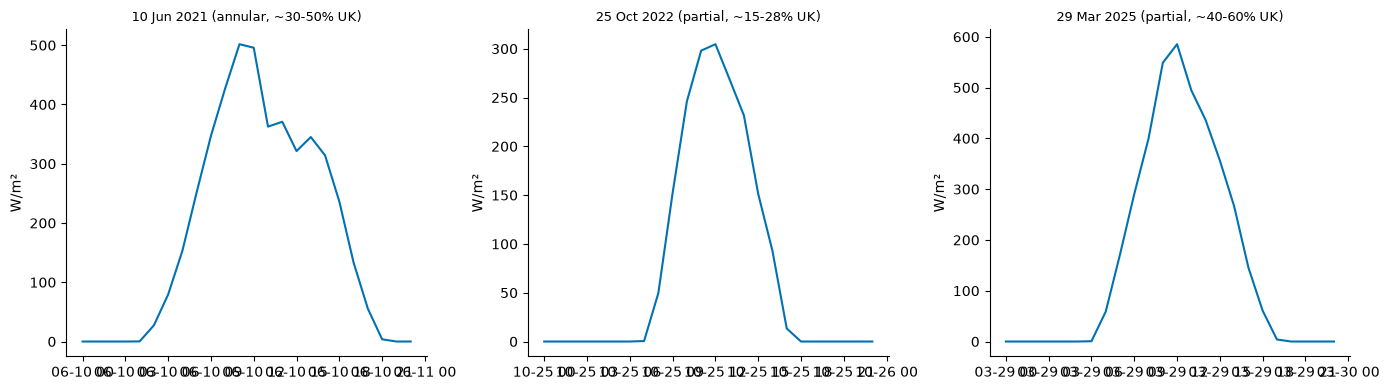

In [6]:
eclipses = [
    ("2021-06-10", "10 Jun 2021 (annular, ~30-50% UK)"),
    ("2022-10-25", "25 Oct 2022 (partial, ~15-28% UK)"),
    ("2025-03-29", "29 Mar 2025 (partial, ~40-60% UK)"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, (date, label) in zip(axes, eclipses):
    window = sources["open_meteo_historical"].loc[date]
    ax.plot(window.index, window["shortwave_radiation_wm2"], color=PALETTE["open_meteo_historical"])
    ax.set_title(label, fontsize=9)
    ax.set_ylabel("W/m²")
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## Seasonality: monthly wind speed and solar radiation by year

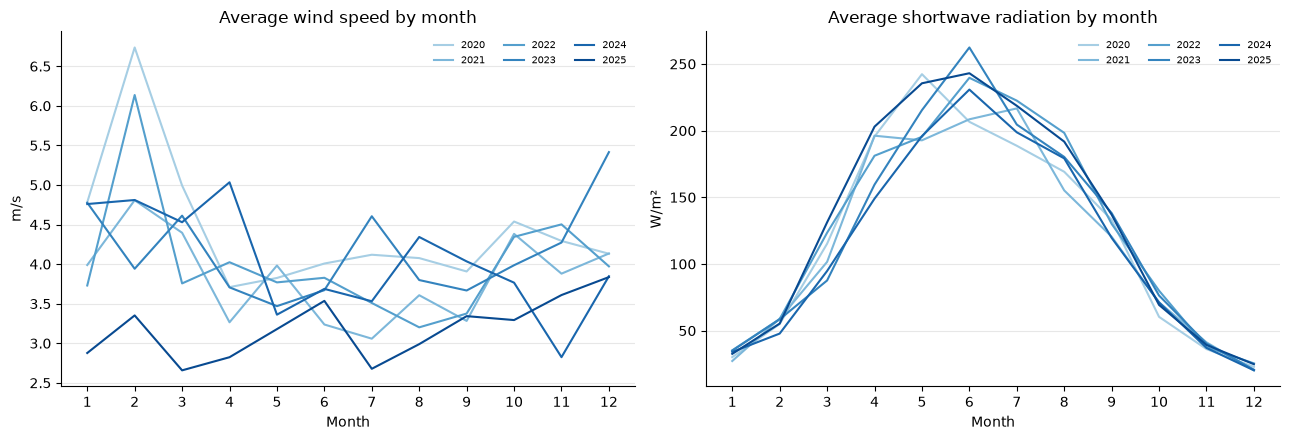

In [7]:
era5 = sources["open_meteo_historical"]
monthly_wind = era5["wind_speed_ms"].groupby([era5.index.year, era5.index.month]).mean().unstack(0)
monthly_solar = era5["shortwave_radiation_wm2"].groupby([era5.index.year, era5.index.month]).mean().unstack(0)

years = sorted(monthly_wind.columns)
colors = plt.cm.Blues([0.35 + 0.55 * i / (len(years) - 1) for i in range(len(years))])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for year, color in zip(years, colors):
    axes[0].plot(monthly_wind.index, monthly_wind[year], color=color, linewidth=1.5, label=str(year))
    axes[1].plot(monthly_solar.index, monthly_solar[year], color=color, linewidth=1.5, label=str(year))
axes[0].set_title("Average wind speed by month")
axes[0].set_ylabel("m/s")
axes[1].set_title("Average shortwave radiation by month")
axes[1].set_ylabel("W/m²")
for ax in axes:
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Month")
    ax.legend(ncol=3, fontsize=7, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

## Notes / next steps

- If the day-ahead MAE isn't clearly larger than the nowcast MAE above, investigate before trusting the day-ahead source in Week 4 — that would suggest a data issue, not a modelling one.
- The eclipse dips (if visible) are a nice sanity check that `shortwave_radiation_wm2` responds to real physical events, not just cloud noise.
- Feed these into Week 3/4 feature engineering: heating/cooling degree days from temperature, and the day-ahead vs. ERA5 gap sets the honest expectation for Week 4's second ablation.